## Data preprocessing

### 00 Cluster-based split - explore

In [4]:
import pandas as pd
import numpy as np

clusters_path = "../data/interim/clusters.tsv"
df = pd.read_csv(clusters_path, sep="\t", header=None, names=["rep", "member"])
df

,rep,member
0,A0A0C5B5G6,A0A0C5B5G6
1,O15263,O15263
2,O15263,Q6QLR2
3,O15263,P81534
4,O15263,Q7TNV9
...,...,...
82399,O17645,P25722
82400,O34327,O34327
82401,O34327,Q59HN8
82402,O34327,P71002


In [10]:
# count clusters and members: 
num_clusters = df['rep'].nunique()
num_members = len(df)
num_clusters, num_members

(35135, 82404)

In [11]:
# cluster size distribution 
cluster_sizes = df.groupby("rep")["member"].count().sort_values(ascending = False)
cluster_sizes.head()

rep
Q8TAQ5    171
P31582    114
Q00043    111
Q96292    101
Q17446     98
Name: member, dtype: int64

<Axes: >

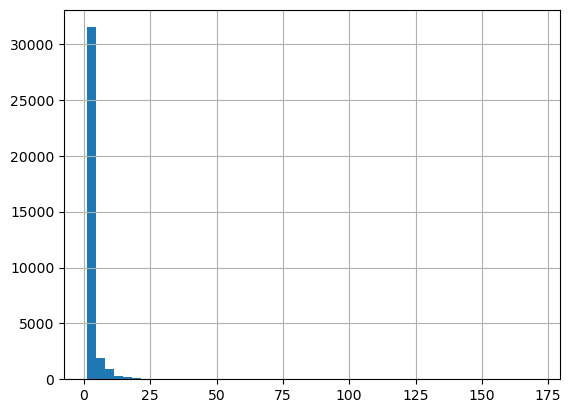

In [12]:
cluster_sizes.hist(bins=50)

In [15]:
# members member IDs of largest family 
top_rep = cluster_sizes.index[0]
df[df["rep"] == top_rep]["member"].tolist()[:20]

['Q8TAQ5',
 'A2RRD8',
 'P52738',
 'E9PYI1',
 'Q76KX8',
 'Q7Z3V5',
 'O94892',
 'Q9GZX5',
 'Q9Y3M9',
 'A6NHJ4',
 'Q9UJL9',
 'Q6ZSS3',
 'Q06732',
 'Q8NDW4',
 'O75123',
 'Q9HCZ1',
 'Q9UC06',
 'Q9NR11',
 'E9QAG8',
 'Q8NEP9']

In [16]:
from collections import defaultdict
clusters = defaultdict(list)
for _,row in df.iterrows(): 
    clusters[row["rep"]].append(row["member"])

len(clusters)

35135

In [18]:
reps = list(clusters.keys())
print("Total cluster representatives:", len(reps))

Total cluster representatives: 35135


In [20]:
import numpy as np

val_ratio = 0.15
rng = np.random.default_rng(42)  # reproducible ordering
rng.shuffle(reps)

n_val = int(len(reps) * val_ratio)

val_reps = set(reps[:n_val])
train_reps = set(reps[n_val:])

len(train_reps), len(val_reps)


(29865, 5270)

In [21]:
train_ids = []
val_ids =[] 

for rep, members in clusters.items():
    if rep in train_reps: 
        train_ids.extend(members)
    else: 
        val_ids.extend(members)

len(train_ids), len(val_ids)

(70093, 12311)

In [23]:
# step 6. Ensure no duplicates
train_ids = set(train_ids)
val_ids = set(val_ids) 
overlap = train_ids & val_ids 
overlap

set()

In [24]:
# 40% similarity 
import os 
os.makedirs("../data/processed", exist_ok = True)

pd.DataFrame({"protein_id": list(train_ids)}).to_csv("../data/processed/train_id_40.csv",index = False)
pd.DataFrame({"protein_id": list(val_ids)}).to_csv("../data/processed/val_id_40.csv", index=False)


### 01  Sequence alignment  

In [2]:
import os

os.makedirs("../data/interim", exist_ok=True)
os.makedirs("../data/raw", exist_ok=True)


In [3]:
cluster_tsv_path = "../data/interim/clusters.tsv"

if os.path.exists(cluster_tsv_path):
    print("clusters.tsv already exists — skipping clustering step.")
else:
    print("clusters.tsv not found — will run MMseqs2 clustering.")


clusters.tsv already exists — skipping clustering step.


#### Sequence alignment 
if not exist run the following cells 

In [ ]:
try:
    !mmseqs
except:
    print("Installing MMseqs2...")
    !apt-get install mmseqs2 -y

In [ ]:
# use similarity 40% for example 
if not os.path.exists(cluster_tsv_path):

    fasta_path = "../data/raw/train_sequences.fasta"   # change if needed

    print("Running MMseqs2 clustering...")

    !mmseqs easy-linclust \
        {fasta_path} \
        ../data/interim/clusters_db \
        ../data/interim/tmp_dir \
        --min-seq-id 0.4 \
        --cov-mode 1 -c 0.8

    # Convert cluster results to TSV
    !mmseqs createtsv \
        {fasta_path} \
        {fasta_path} \
        ../data/interim/clusters_db \
        {cluster_tsv_path}

    print("Clustering completed and clusters.tsv saved!")
else:
    print("Skipping — clusters.tsv already exists.")

# loading results 
df = pd.read_csv(cluster_tsv_path, sep="\t", header=None, names=["rep", "member"])
print(df.head(), df.shape)

### 02 Train test split

In [ ]:
from src.preprocessing.create_split import load_clusters, split_clusters, save_split

clusters = load_clusters("../data/interim/clusters.tsv")
train_ids, val_ids = split_clusters(clusters, val_ratio=0.15, seed=42)
save_split(train_ids, val_ids, "../data/processed")